<div class="jumbotron text-left"><b>
    
This tutorial describes how to use de DesignSpace within the SMT toolbox.
<div>
    
    February 2026 - `SMT version 2.10.1`
  
     Paul Saves (IRIT/SMAC), Jasper Bussemaker (DLR), Rémi Lafage (ONERA/DTIS/MIDL) and Nathalie BARTOLI (ONERA/DTIS/M2CI)

<div class="alert alert-info fade in" id="d110">
<p>Some updates</p>
<ol> -  Manipulation of mixed DOE (continuous, integer,  categorical and hierarchical variables) </ol>
</div>

<p class="alert alert-success" style="padding:1em">
To use SMT models, please follow this link : https://github.com/SMTorg/SMT/blob/master/README.md. The documentation is available here: http://smt.readthedocs.io/en/latest/
</p>

The reference paper is available
here https://www.sciencedirect.com/science/article/pii/S096599782300162X



For mixed integer with continuous relaxation, the reference paper is available here https://www.sciencedirect.com/science/article/pii/S0925231219315619

In [18]:
# to have the latest version
!pip install configspace
!pip install adsg-core
!pip install smt-design-space-ext
!pip install smt
!pip install "adsg-core[nb]"

<div class="alert alert-warning" >
If you use hierarchical variables and the size of your doe greater than 30 points, you may leverage the `numba` JIT compiler to speed up the computation
To do so:
    
 - install numba library
    
     `pip install numba`
    
    
 - and define the environment variable `USE_NUMBA_JIT = 1` (unset or 0 if you do not want to use numba)
    
     - Linux: export USE_NUMBA_JIT = 1
    
     - Windows: set USE_NUMBA_JIT = 1

</div>

In [19]:
%matplotlib inline

# to ignore warning messages
import warnings

import plotly.io as pio
from smt.sampling_methods import LHS
from smt_design_space_ext import (
    AdsgDesignSpaceImpl,
    CategoricalVariable,
    ConfigSpaceDesignSpaceImpl,
    DesignSpace,
    FloatVariable,
    IntegerVariable,
    OrdinalVariable,
)

warnings.filterwarnings("ignore")

pio.renderers.default = "notebook"

# MAELIA

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from smt.design_space import FloatVariable, OrdinalVariable, CategoricalVariable
from smt_design_space_ext import AdsgDesignSpaceImpl
from smt.surrogate_models import KRG

# ==========================================
# 1. PARAMÈTRES ET "VALUE TAGGING"
# ==========================================
# On rend TOUTES les variables discrètes uniques pour neutraliser le mélange de l'ADSG
prepa_types = ["Labour", "Preparation du lit de semence", "Déchaumage", "Roulage"]
ferti_types = ["N_solution", "AN", "mineral", "urea"]

agri_design_space = AdsgDesignSpaceImpl(
    design_variables=[
        # --- BLOC DISCRET (Avec Tags Uniques) ---
        OrdinalVariable(["0_ferti", "1_ferti", "2_ferti", "3_ferti"]), # 0: n_ferti
        OrdinalVariable(["Non_prepa", "Oui_prepa"]),                   # 1: has_prepa 
        OrdinalVariable(["1_prepa", "2_prepa"]),                       # 2: nb_prepa 
        CategoricalVariable([p + "_p1" for p in prepa_types]),         # 3: prepa_1
        CategoricalVariable([p + "_p2" for p in prepa_types]),         # 4: prepa_2 
        
        OrdinalVariable(["1_f1", "2_f1"]),                             # 5: Nb produits F1
        CategoricalVariable([f + "_f11" for f in ferti_types]),        # 6: type F1_1
        CategoricalVariable([f + "_f12" for f in ferti_types]),        # 7: type F1_2
        
        OrdinalVariable(["1_f2", "2_f2"]),                             # 8: Nb produits F2
        CategoricalVariable([f + "_f21" for f in ferti_types]),        # 9: type F2_1
        CategoricalVariable([f + "_f22" for f in ferti_types]),        # 10: type F2_2
        
        OrdinalVariable(["1_f3", "2_f3"]),                             # 11: Nb produits F3
        CategoricalVariable([f + "_f31" for f in ferti_types]),        # 12: type F3_1
        CategoricalVariable([f + "_f32" for f in ferti_types]),        # 13: type F3_2
        
        # --- BLOC CONTINU (L'ADSG préserve leur ordre relatif à la fin) ---
        FloatVariable(45, 106),                 # 14: Semi_date
        FloatVariable(-44, -4),                 # 15: Jours Semi -> PREPA
        FloatVariable(106, 323),                 # 16: F1_date -> Peut couvrir TOUT le printemps (Fév à Juin) si unique !
        FloatVariable(210, 323),                 # 17: F2_date -> Fenêtre active si n_ferti >= 2
        FloatVariable(240, 323),                 # 18: F3_date -> Fenêtre active si n_ferti = 3 
        FloatVariable(323, 384),                # 19: Jours Recolte
        
        FloatVariable(10, 100),                 # 20: dose F1_1
        FloatVariable(10, 100),                 # 21: dose F1_2
        FloatVariable(10, 100),                 # 22: dose F2_1
        FloatVariable(10, 100),                 # 23: dose F2_2
        FloatVariable(10, 100),                 # 24: dose F3_1
        FloatVariable(10, 100),                 # 25: dose F3_2
    ]
)

# ==========================================
# 2. HIÉRARCHIE D'ACTIVATION (ADSG)
# ==========================================
# Les meta_value doivent correspondre à nos nouveaux Tags Uniques
agri_design_space.declare_decreed_var(decreed_var=2,  meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=3,  meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=15, meta_var=1, meta_value=["Oui_prepa"])
agri_design_space.declare_decreed_var(decreed_var=4,  meta_var=2, meta_value=["2_prepa"])

agri_design_space.declare_decreed_var(decreed_var=16, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=5,  meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=6,  meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=20, meta_var=0, meta_value=["1_ferti", "2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=7,  meta_var=5, meta_value=["2_f1"])
agri_design_space.declare_decreed_var(decreed_var=21, meta_var=5, meta_value=["2_f1"])

agri_design_space.declare_decreed_var(decreed_var=17, meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=8,  meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=9,  meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=22, meta_var=0, meta_value=["2_ferti", "3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=10, meta_var=8, meta_value=["2_f2"])
agri_design_space.declare_decreed_var(decreed_var=23, meta_var=8, meta_value=["2_f2"])

agri_design_space.declare_decreed_var(decreed_var=18, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=11, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=12, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=24, meta_var=0, meta_value=["3_ferti"])
agri_design_space.declare_decreed_var(decreed_var=13, meta_var=11, meta_value=["2_f3"])
agri_design_space.declare_decreed_var(decreed_var=25, meta_var=11, meta_value=["2_f3"])

# SMT applique var1 < var2 (Empêche l'inversion des apports si plusieurs sont actifs)
agri_design_space.add_value_constraint(var1=18, value1="<", var2=17, value2=">")  # F1 < F2
agri_design_space.add_value_constraint(var1=17, value1="<", var2=16, value2=">")  # F2 < F3
agri_design_space.add_value_constraint(
    var1=4, value1=["Labour_p2"], var2=2, value2=["2_prepa"]
) 
agri_design_space.add_value_constraint(
    var1=3, value1=["Labour_p1"], var2=2, value2=["2_prepa"]
) 


# ==========================================
# 3. MOTEUR D'EXTRACTION BLINDÉ
# ==========================================
def parse_smt_row(row_data):
    """ Analyse une ligne décodée par SMT en cherchant nos tags uniques """
    parsed = {
        "n_ferti": 0, "has_prepa": False, "nb_prepa": 1, "nb_f1": 1, "nb_f2": 1, "nb_f3": 1,
        "prepa_t1": "-", "prepa_t2": "-", "f1_t1": "-", "f1_t2": "-", 
        "f2_t1": "-", "f2_t2": "-", "f3_t1": "-", "f3_t2": "-", "floats": []
    }
    
    # Sécurise la lecture si SMT renvoie un dictionnaire ou une liste
    values = list(row_data.values()) if isinstance(row_data, dict) else row_data
    
    for val in values:
        if isinstance(val, (float, int)):
            parsed["floats"].append(float(val))
        elif isinstance(val, str):
            if "_ferti" in val: parsed["n_ferti"] = int(val[0])
            elif val in ["Oui_prepa", "Non_prepa"]: parsed["has_prepa"] = (val == "Oui_prepa")
            elif "_prepa" in val: parsed["nb_prepa"] = int(val[0])
            elif "_p1" in val: parsed["prepa_t1"] = val.replace("_p1", "")
            elif "_p2" in val: parsed["prepa_t2"] = val.replace("_p2", "")
            elif "_f11" in val: parsed["f1_t1"] = val.replace("_f11", "")
            elif "_f12" in val: parsed["f1_t2"] = val.replace("_f12", "")
            elif val in ["1_f1", "2_f1"]: parsed["nb_f1"] = int(val[0])
            elif "_f21" in val: parsed["f2_t1"] = val.replace("_f21", "")
            elif "_f22" in val: parsed["f2_t2"] = val.replace("_f22", "")
            elif val in ["1_f2", "2_f2"]: parsed["nb_f2"] = int(val[0])
            elif "_f31" in val: parsed["f3_t1"] = val.replace("_f31", "")
            elif "_f32" in val: parsed["f3_t2"] = val.replace("_f32", "")
            elif val in ["1_f3", "2_f3"]: parsed["nb_f3"] = int(val[0])
            
    return parsed

    
def extract_table_from_smt(x_array, dsg_space):
    results = []
    decoded_data = dsg_space.decode_values(x_array)
    
    for row_data in decoded_data:
        p = parse_smt_row(row_data)
        fl = p["floats"] # Les 12 variables continues restent toujours dans leur ordre
        
        semi = int(round(fl[0]))
        recolte = int(round(fl[5]))
        duree_cycle = int(round(recolte - semi))
        
        if p["has_prepa"]:
            prepa_date = int(round(semi + fl[1]))
            p2 = p["prepa_t2"] if p["nb_prepa"] == 2 else "-"
        else:
            prepa_date = None
            p["prepa_t1"] = p2 = "-"

        base_f1 = prepa_date if p["has_prepa"] else semi
        
        if p["n_ferti"] >= 1:
            f1_date = int(round(fl[2]))
            f1_d1 = round(fl[6], 1)
            f1_t2 = p["f1_t2"] if p["nb_f1"] == 2 else "-"
            f1_d2 = round(fl[7], 1) if p["nb_f1"] == 2 else "-"
        else:
            f1_date = None
            p["f1_t1"] = f1_d1 = f1_t2 = f1_d2 = "-"

        if p["n_ferti"] >= 2:
            f2_date = int(round(fl[3]))
            while (f2_date <= f1_date)  : 
                f1_date = int(np.random.uniform(106, 323))
                f2_date = int(np.random.uniform(210, 323))
            
                
            f2_d1 = round(fl[8], 1)
            f2_t2 = p["f2_t2"] if p["nb_f2"] == 2 else "-"
            f2_d2 = round(fl[9], 1) if p["nb_f2"] == 2 else "-"
        else:
            f2_date = None
            p["f2_t1"] = f2_d1 = f2_t2 = f2_d2 = "-"

        if p["n_ferti"] >= 3:
            f3_date = int(round(fl[4]))
            while (f2_date <= f1_date or f3_date <= f2_date )   : 
                f1_date = int(np.random.uniform(106, 323))
                f2_date = int(np.random.uniform(210, 323))
                f3_date = int(np.random.uniform(240, 323))

            
            f3_d1 = round(fl[10], 1)
            f3_t2 = p["f3_t2"] if p["nb_f3"] == 2 else "-"
            f3_d2 = round(fl[11], 1) if p["nb_f3"] == 2 else "-"
        else:
            f3_date = None
            p["f3_t1"] = f3_d1 = f3_t2 = f3_d2 = "-"

        last_date = f3_date if f3_date else (f2_date if f2_date else (f1_date if f1_date else (prepa_date if prepa_date else semi)))
        recolte = int(round(fl[5]))

        results.append({
            "n_ferti": p["n_ferti"], "has_prepa": "Oui" if p["has_prepa"] else "Non", "Semi": semi,
            "PREPA_Date": prepa_date if p["has_prepa"] else "-", "PREPA_Type_1": p["prepa_t1"], "PREPA_Type_2": p2,
            "Ferti_1": f1_date if f1_date else "-", "F1_Type_1": p["f1_t1"], "F1_Dose_1": f1_d1, "F1_Type_2": f1_t2, "F1_Dose_2": f1_d2,
            "Ferti_2": f2_date if f2_date else "-", "F2_Type_1": p["f2_t1"], "F2_Dose_1": f2_d1, "F2_Type_2": f2_t2, "F2_Dose_2": f2_d2,
            "Ferti_3": f3_date if f3_date else "-", "F3_Type_1": p["f3_t1"], "F3_Dose_1": f3_d1, "F3_Type_2": f3_t2, "F3_Dose_2": f3_d2,
            "Recolte": recolte
        })

    return pd.DataFrame(results)

# ==========================================
# 4. GESTION DES DONNÉES (MAELIA DUMMY)
# ==========================================
def evaluate_maelia_dummy(x_array, dsg_space):
    y = np.zeros((x_array.shape[0], 1))
    decoded_data = dsg_space.decode_values(x_array)
    
    for i, row_data in enumerate(decoded_data):
        p = parse_smt_row(row_data)
        fl = p["floats"]
        dose_totale = 0
        
        if p["n_ferti"] >= 1:
            dose_totale += fl[6]
            if p["nb_f1"] == 2: dose_totale += fl[7]
        if p["n_ferti"] >= 2:
            dose_totale += fl[8]
            if p["nb_f2"] == 2: dose_totale += fl[9]
        if p["n_ferti"] >= 3:
            dose_totale += fl[10]
            if p["nb_f3"] == 2: dose_totale += fl[11]
            
        y[i, 0] = 50 + (dose_totale * 0.25) - (0.0006 * dose_totale**2) + 0.1#np.random.normal(0, 1.5)
    return y




In [23]:
N_DOE = 30
print(f"Génération de {N_DOE} points LHS hiérarchiques (SMT ADSG)...")

from smt.applications.mixed_integer import MixedIntegerSamplingMethod
from smt.sampling_methods import LHS

# On NE PASSE PLUS par xlimits_relaxed
# On donne directement le design_space (qui contient la nature des variables) au wrapper

# 1. Configuration du sampler
sampler = MixedIntegerSamplingMethod(
    LHS, 
    agri_design_space, 
    criterion="ese", 
    seed=42 # Note: SMT utilise souvent random_state au lieu de seed
)


xt_raw = sampler(N_DOE)
xt, _ = agri_design_space.correct_get_acting(xt_raw)

# --- Robust deduplication ---
def is_new(row, X, tol=1e-8):
    return not any(np.allclose(row, x, atol=tol) for x in X)

xt_unique = []
for row in xt:
    if is_new(row, xt_unique):
        xt_unique.append(row)

xt = np.array(xt_unique)

if xt.shape[0] < N_DOE:
    print("{N_DOE - xt.shape[0]} duplicates after projection")

# --- Resampling (batch, not 1-by-1) ---
while xt.shape[0] < N_DOE:
    n_missing = N_DOE - xt.shape[0]
    xt_new = sampler(n_missing * 2)
    xt_corr, _ = agri_design_space.correct_get_acting(xt_new)

    for row in xt_corr:
        if is_new(row, xt):
            xt = np.vstack([xt, row])
        if xt.shape[0] >= N_DOE:
            break

# --- Critical step ---
xt,_ = agri_design_space.correct_get_acting(xt)

print(f"Matrice DOE : {xt.shape[0]} × {xt.shape[1]} variables\n")


Génération de 30 points LHS hiérarchiques (SMT ADSG)...
Matrice DOE : 30 × 26 variables



In [24]:
doe_display = extract_table_from_smt(xt, agri_design_space)
display(doe_display.iloc[:, :10])
display(doe_display.iloc[:, 10:])

yt = evaluate_maelia_dummy(xt, agri_design_space)

,n_ferti,has_prepa,Semi,PREPA_Date,PREPA_Type_1,PREPA_Type_2,Ferti_1,F1_Type_1,F1_Dose_1,F1_Type_2
0,1,Oui,50,33,Déchaumage,-,183,mineral,48.2,-
1,1,Oui,63,28,Preparationdulitdesemence,Roulage,108,mineral,85.8,-
2,3,Oui,65,46,Déchaumage,Déchaumage,260,urea,96.3,mineral
3,0,Non,94,-,-,-,-,-,-,-
4,3,Oui,90,72,Déchaumage,Preparationdulitdesemence,242,urea,93.8,-
5,3,Oui,50,26,Déchaumage,-,216,mineral,86.7,-
6,0,Non,75,-,-,-,-,-,-,-
7,3,Oui,86,75,Déchaumage,Preparationdulitdesemence,185,mineral,44.0,-
8,0,Oui,47,15,Preparationdulitdesemence,Roulage,-,-,-,-
9,0,Non,102,-,-,-,-,-,-,-


,F1_Dose_2,Ferti_2,F2_Type_1,F2_Dose_1,F2_Type_2,F2_Dose_2,Ferti_3,F3_Type_1,F3_Dose_1,F3_Type_2,F3_Dose_2,Recolte
0,-,-,-,-,-,-,-,-,-,-,-,330
1,-,-,-,-,-,-,-,-,-,-,-,327
2,98.8,293,N_solution,42.8,-,-,295,urea,40.5,urea,35.1,353
3,-,-,-,-,-,-,-,-,-,-,-,335
4,-,251,N_solution,44.5,mineral,68.3,258,urea,81.3,urea,54.3,359
5,-,266,AN,22.1,-,-,273,N_solution,52.5,-,-,369
6,-,-,-,-,-,-,-,-,-,-,-,340
7,-,251,N_solution,56.7,mineral,99.6,264,AN,23.2,-,-,359
8,-,-,-,-,-,-,-,-,-,-,-,369
9,-,-,-,-,-,-,-,-,-,-,-,323


=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION ===


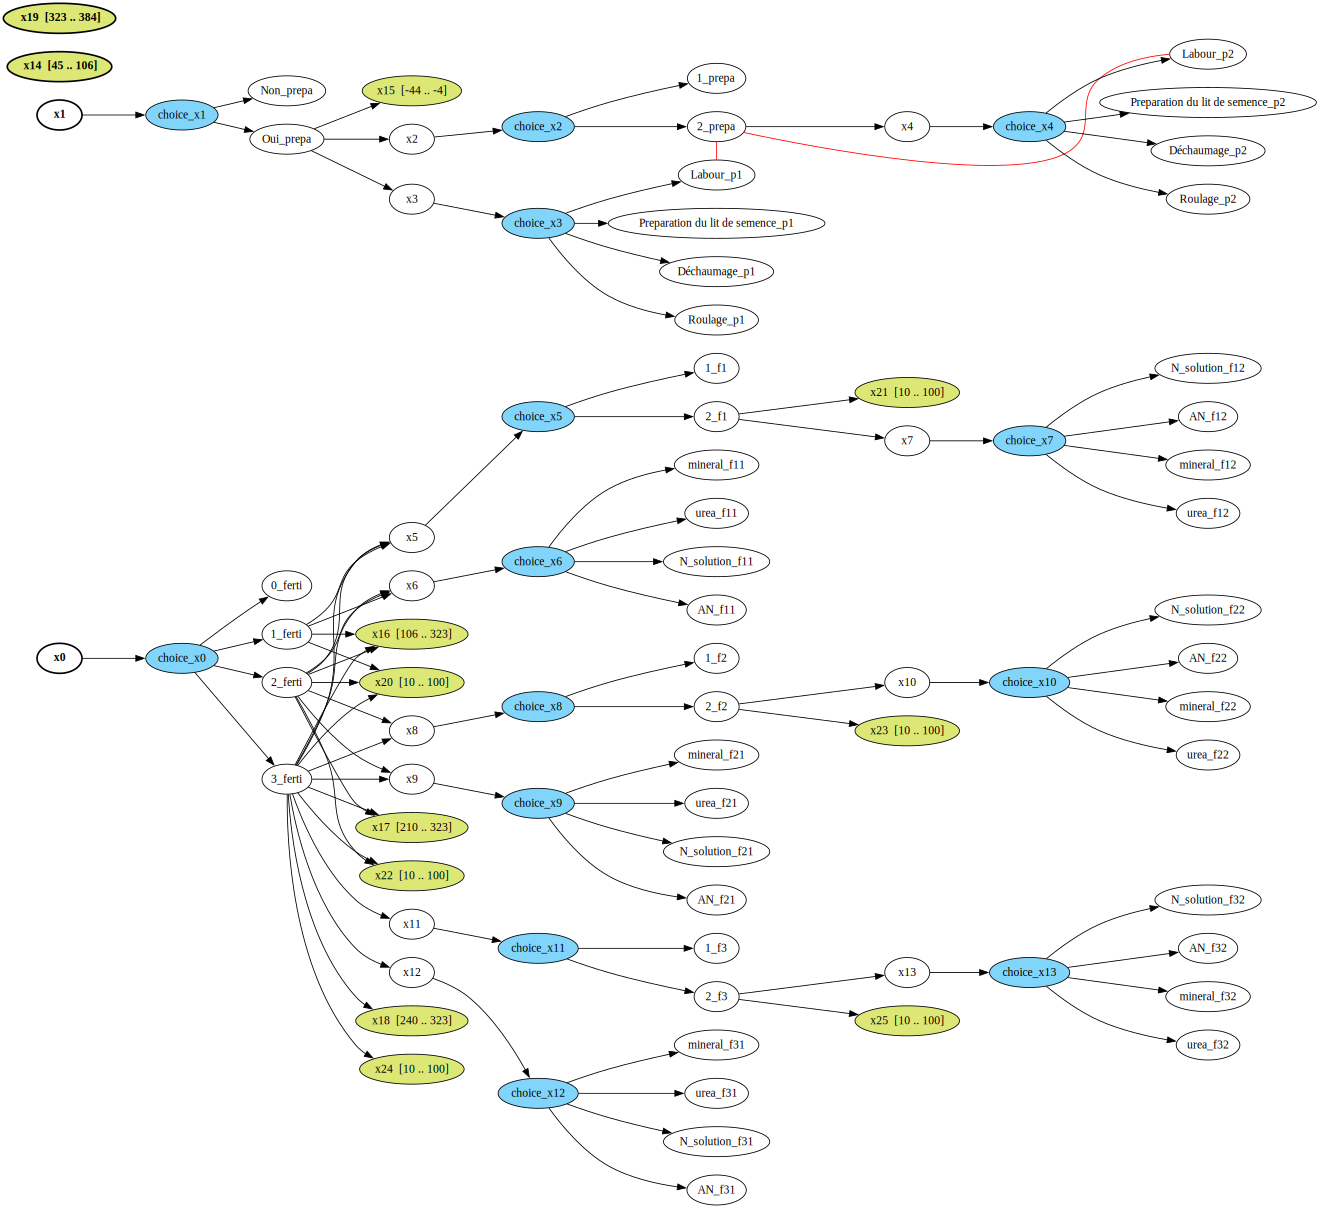

In [25]:
from graphviz import Source
from IPython.display import display

def render_to_image(dsg_obj, filename="temp_graph"):
    dot_str = dsg_obj.export_dot()
    
    # Injection des paramètres de layout dans le DOT
    layout_config = """
    graph [
        rankdir=LR,
        nodesep=0.3,
        ranksep=0.5,
        splines=true,
        margin=0
    ];
    """
    
    # On insère juste après "digraph ..."
    dot_str = dot_str.replace("{", "{\n" + layout_config, 1)
    
    src = Source(dot_str, filename=filename, format="png", engine="dot")
    
    display(src)

print("=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION ===")
render_to_image(agri_design_space.adsg, "maelia_space")

=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION MAELIA ===


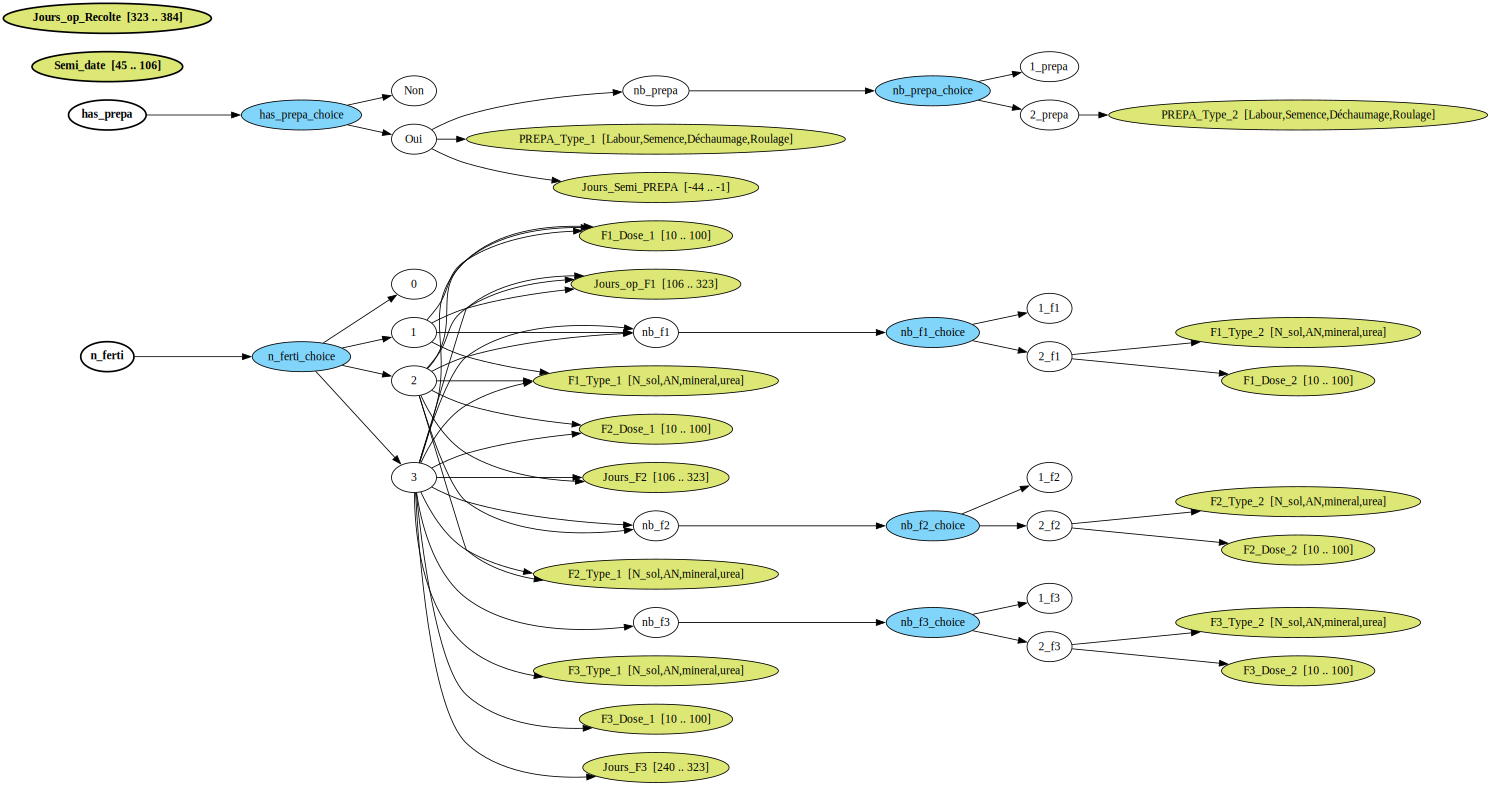

In [27]:
from adsg_core import BasicADSG, DesignVariableNode, NamedNode
from graphviz import Source
from IPython.display import display

def create_explicit_maelia_adsg():
    adsg = BasicADSG()

    # --- 1. CONSTANTS ---
    PREPA_TYPES = ["Labour", "Semence", "Déchaumage", "Roulage"]
    FERTI_TYPES = ["N_sol", "AN", "mineral", "urea"]

    # --- 2. ROOT NODES (Always Active) ---
    n_ferti = NamedNode("n_ferti")
    n_ferti_opts = [NamedNode("0"), NamedNode("1"), NamedNode("2"), NamedNode("3")]
    adsg.add_selection_choice("n_ferti_choice", n_ferti, n_ferti_opts)

    has_prepa = NamedNode("has_prepa")
    has_prepa_opts = [NamedNode("Non"), NamedNode("Oui")]
    adsg.add_selection_choice("has_prepa_choice", has_prepa, has_prepa_opts)

    semi_date = DesignVariableNode("Semi_date", bounds=(45, 106))
    jours_recolte = DesignVariableNode("Jours_op_Recolte", bounds=(323, 384))

    adsg.add_node(semi_date)
    adsg.add_node(jours_recolte)

    # --- 3. PREPARATION HIERARCHY ---
    nb_prepa = NamedNode("nb_prepa")
    nb_prepa_opts = [NamedNode("1_prepa"), NamedNode("2_prepa")]
    adsg.add_selection_choice("nb_prepa_choice", nb_prepa, nb_prepa_opts)

    prepa_1_type = DesignVariableNode("PREPA_Type_1", options=PREPA_TYPES)
    jours_prepa = DesignVariableNode("Jours_Semi_PREPA", bounds=(-44, -1))

    for node in [nb_prepa, prepa_1_type, jours_prepa]:
        adsg.add_edge(has_prepa_opts[1], node)

    prepa_2_type = DesignVariableNode("PREPA_Type_2", options=PREPA_TYPES)
    adsg.add_edge(nb_prepa_opts[1], prepa_2_type)

    # --- 4. FERTILIZATION HIERARCHY ---

    # Ferti 1
    nb_f1 = NamedNode("nb_f1")
    nb_f1_opts = [NamedNode("1_f1"), NamedNode("2_f1")]
    adsg.add_selection_choice("nb_f1_choice", nb_f1, nb_f1_opts)

    f1_t1 = DesignVariableNode("F1_Type_1", options=FERTI_TYPES)
    f1_d1 = DesignVariableNode("F1_Dose_1", bounds=(10, 100))
    jours_f1 = DesignVariableNode("Jours_op_F1", bounds=(106, 323))

    for opt_idx in [1, 2, 3]:
        for node in [nb_f1, f1_t1, f1_d1, jours_f1]:
            adsg.add_edge(n_ferti_opts[opt_idx], node)

    f1_t2 = DesignVariableNode("F1_Type_2", options=FERTI_TYPES)
    f1_d2 = DesignVariableNode("F1_Dose_2", bounds=(10, 100))
    adsg.add_edges([(nb_f1_opts[1], f1_t2), (nb_f1_opts[1], f1_d2)])

    # Ferti 2
    nb_f2 = NamedNode("nb_f2")
    nb_f2_opts = [NamedNode("1_f2"), NamedNode("2_f2")]
    adsg.add_selection_choice("nb_f2_choice", nb_f2, nb_f2_opts)

    f2_t1 = DesignVariableNode("F2_Type_1", options=FERTI_TYPES)
    f2_d1 = DesignVariableNode("F2_Dose_1", bounds=(10, 100))
    jours_f2 = DesignVariableNode("Jours_F2", bounds=(106, 323))

    for opt_idx in [2, 3]:
        for node in [nb_f2, f2_t1, f2_d1, jours_f2]:
            adsg.add_edge(n_ferti_opts[opt_idx], node)

    f2_t2 = DesignVariableNode("F2_Type_2", options=FERTI_TYPES)
    f2_d2 = DesignVariableNode("F2_Dose_2", bounds=(10, 100))
    adsg.add_edges([(nb_f2_opts[1], f2_t2), (nb_f2_opts[1], f2_d2)])

    # Ferti 3
    nb_f3 = NamedNode("nb_f3")
    nb_f3_opts = [NamedNode("1_f3"), NamedNode("2_f3")]
    adsg.add_selection_choice("nb_f3_choice", nb_f3, nb_f3_opts)

    f3_t1 = DesignVariableNode("F3_Type_1", options=FERTI_TYPES)
    f3_d1 = DesignVariableNode("F3_Dose_1", bounds=(10, 100))
    jours_f3 = DesignVariableNode("Jours_F3", bounds=(240, 323))

    for node in [nb_f3, f3_t1, f3_d1, jours_f3]:
        adsg.add_edge(n_ferti_opts[3], node)

    f3_t2 = DesignVariableNode("F3_Type_2", options=FERTI_TYPES)
    f3_d2 = DesignVariableNode("F3_Dose_2", bounds=(10, 100))
    adsg.add_edges([(nb_f3_opts[1], f3_t2), (nb_f3_opts[1], f3_d2)])

    # --- 5. INITIALIZE GRAPH START NODES ---
    adsg = adsg.set_start_nodes({n_ferti, has_prepa, semi_date, jours_recolte})

    return adsg


def render_to_image(dsg_obj, filename="temp_graph"):
    dot_str = dsg_obj.export_dot()

    layout_config = """
    graph [
        rankdir=LR,
        nodesep=0.3,
        ranksep=0.5,
        splines=true,
        margin=0
    ];
    """

    dot_str = dot_str.replace("{", "{\n" + layout_config, 1)

    src = Source(dot_str, filename=filename, format="png", engine="dot")
    display(src)


maelia_adsg = create_explicit_maelia_adsg()

print("=== GRAPHE GLOBAL DE L'ESPACE DE CONCEPTION MAELIA ===")
render_to_image(maelia_adsg, "maelia_adsg")

In [ ]:
print("\nEntraînement du Krigeage Hiérarchique SMT (KRG)...")
sm = KRG(design_space=agri_design_space, print_global=False,noise0=[0.01],corr='pow_exp')
sm.set_training_values(xt, yt)
sm.train()
print("Modèle entraîné !")


In [ ]:

xtest, is_acting_test = agri_design_space._sample_valid_x(30)
ytest_vrai = evaluate_maelia_dummy(xtest, agri_design_space)
ytest_predit = sm.predict_values(xtest)

plt.figure(figsize=(8, 6))
plt.scatter(ytest_vrai, ytest_predit, color='#2ca02c', edgecolors='k', s=60, alpha=0.8, label="Prédictions SMT")
plt.plot([ytest_vrai.min(), ytest_vrai.max()], [ytest_vrai.min(), ytest_vrai.max()], 'r--', lw=2, label="Parfait (Y = X)")
plt.xlabel("Vrai Rendement (MAELIA)")
plt.ylabel("Rendement Prédit (Surrogate)")
plt.title("Validation du Krigeage Hiérarchique SMT")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
ytest_vrai = evaluate_maelia_dummy(xt, agri_design_space)
ytest_predit = sm.predict_values(xt)

plt.figure(figsize=(8, 6))
plt.scatter(ytest_vrai, ytest_predit, color='#2ca02c', edgecolors='k', s=60, alpha=0.8, label="Prédictions SMT")
plt.plot([ytest_vrai.min(), ytest_vrai.max()], [ytest_vrai.min(), ytest_vrai.max()], 'r--', lw=2, label="Parfait (Y = X)")
plt.xlabel("Vrai Rendement (MAELIA)")
plt.ylabel("Rendement Prédit (Surrogate)")
plt.title("Validation du Krigeage Hiérarchique SMT")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()